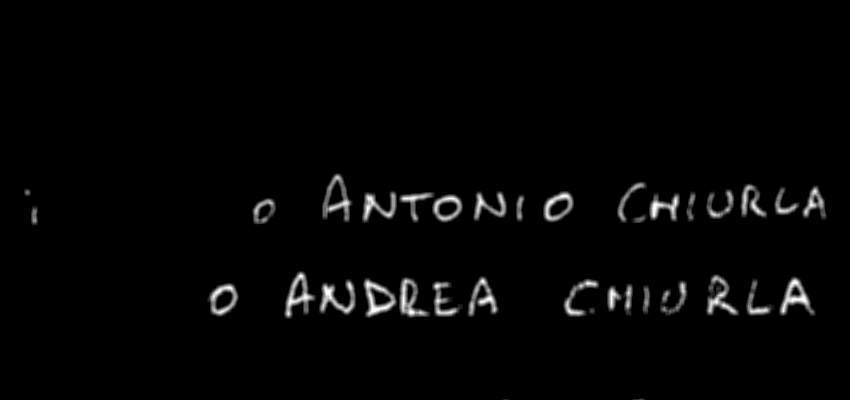

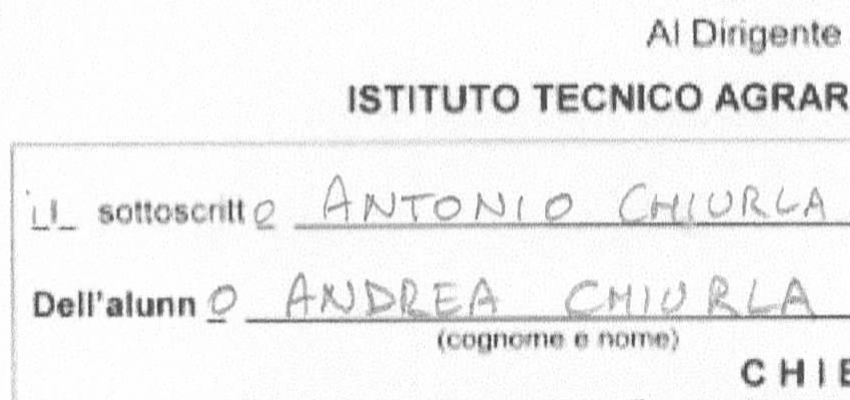

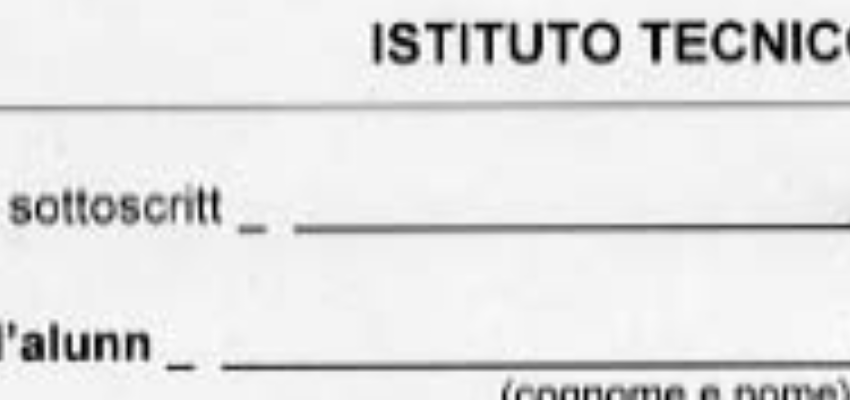

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, Javascript
import json
import fitz  # PyMuPDF
import cv2
import numpy as np
import easyocr
import pytesseract

from snippets.modules.pipeline import Pipeline
from snippets.modules.filters import FILTER_REGISTRY, FILTER_DESCRIPTIONS
import PIL.Image

# --- Caricamento risorse ---
img_empty = cv2.imread("../Lezione2/in/modello.jpg")
doc = fitz.open("../Lezione2/in/modello-riempito-300dpi.pdf")
zoom = 4.16
mat = fitz.Matrix(zoom, zoom)
easyocr_reader = easyocr.Reader(['it'], gpu=True)

# ---------------------------------------------------------------------------
# Stato globale
# ---------------------------------------------------------------------------
page = doc[0]
_ocr_ready_image = None

pipeline_steps = []

# ---------------------------------------------------------------------------
# Helpers widget
# ---------------------------------------------------------------------------

def _info_icon(text):
    safe = text.replace('"', '&quot;')
    return widgets.HTML(
        value=f'<span title="{safe}" style="cursor:help; color:#888; font-size:14px; margin-left:6px;">ℹ</span>'
    )


def _labeled(widget, tooltip_text):
    if tooltip_text:
        return widgets.HBox([widget, _info_icon(tooltip_text)])
    return widget


def _make_param_widget(param_name, default_val, ranges, options, descriptions, odd_params):
    style  = {'description_width': '130px'}
    layout = widgets.Layout(width='380px')

    if param_name in options:
        opts = options[param_name]
        raw = widgets.Dropdown(options=opts, value=default_val,
                               description=param_name, style=style, layout=layout)
    elif isinstance(default_val, bool):
        raw = widgets.Checkbox(value=default_val, description=param_name,
                               style=style, layout=layout)
    elif isinstance(default_val, int):
        rng  = ranges.get(param_name, (None, None))
        lo   = rng[0] if rng[0] is not None else 0
        hi   = rng[1] if rng[1] is not None else 100
        is_odd = param_name in odd_params
        if is_odd:
            lo = lo if lo % 2 == 1 else lo + 1
        raw = widgets.IntSlider(
            value=default_val, min=lo, max=hi,
            step=2 if is_odd else 1,
            description=param_name, style=style, layout=layout,
            continuous_update=False)
    elif isinstance(default_val, float):
        rng = ranges.get(param_name, (None, None))
        lo  = rng[0] if rng[0] is not None else 0.0
        hi  = rng[1] if rng[1] is not None else 10.0
        raw = widgets.FloatSlider(
            value=default_val, min=lo, max=hi, step=0.1,
            description=param_name, style=style, layout=layout,
            continuous_update=False)
    elif isinstance(default_val, str):
        opts = options.get(param_name, [default_val])
        raw = widgets.Dropdown(options=opts, value=default_val,
                               description=param_name, style=style, layout=layout)
    else:
        raw = widgets.Label(value=f"{param_name}: {default_val}")

    return raw, _labeled(raw, descriptions.get(param_name, ""))


_btn_layout = widgets.Layout(width='32px', height='28px')

def _build_step_widget(step_index):
    step          = pipeline_steps[step_index]
    filter_name   = step['name']
    enabled_cb    = step['enabled']
    param_widgets = step['param_widgets']
    raw_widgets   = step['raw_widgets']
    n             = len(pipeline_steps)

    params_box = widgets.VBox(list(param_widgets.values()))
    up_btn     = widgets.Button(description='▲', layout=_btn_layout, disabled=(step_index == 0))
    down_btn   = widgets.Button(description='▼', layout=_btn_layout, disabled=(step_index == n - 1))
    remove_btn = widgets.Button(description='✕', button_style='danger', layout=_btn_layout)

    desc = FILTER_DESCRIPTIONS.get(filter_name, "")
    safe_desc = desc.replace('"', '&quot;')
    filter_label = widgets.HTML(
        value=f'<b title="{safe_desc}" style="cursor:help;">{filter_name}</b>'
              + (f' <span title="{safe_desc}" style="cursor:help; color:#888; font-size:13px;">ℹ</span>' if desc else "")
    )

    header   = widgets.HBox([enabled_cb, up_btn, down_btn, filter_label, remove_btn])
    step_box = widgets.VBox([header, params_box],
                             layout=widgets.Layout(border='1px solid #ccc',
                                                   padding='6px', margin='4px 0'))

    def on_remove(_):
        pipeline_steps.pop(step_index); _refresh_pipeline_ui(); _apply()

    def on_up(_):
        pipeline_steps[step_index-1], pipeline_steps[step_index] = \
            pipeline_steps[step_index], pipeline_steps[step_index-1]
        _refresh_pipeline_ui(); _apply()

    def on_down(_):
        pipeline_steps[step_index+1], pipeline_steps[step_index] = \
            pipeline_steps[step_index], pipeline_steps[step_index+1]
        _refresh_pipeline_ui(); _apply()

    remove_btn.on_click(on_remove)
    up_btn.on_click(on_up)
    down_btn.on_click(on_down)
    enabled_cb.observe(lambda _: _apply(), names='value')
    for w in raw_widgets.values():
        w.observe(lambda _: _apply(), names='value')

    return step_box


# ---------------------------------------------------------------------------
# Pipeline UI container
# ---------------------------------------------------------------------------
pipeline_container = widgets.VBox([])

def _refresh_pipeline_ui():
    pipeline_container.children = [_build_step_widget(i) for i in range(len(pipeline_steps))]
    steps_label.value = (f"<i>{len(pipeline_steps)} filtro/i in pipeline</i>"
                         if pipeline_steps else "<i>Nessun filtro aggiunto</i>")


def _add_filter(_):
    filter_name    = filter_dropdown.value
    info           = Pipeline.available_filters()[filter_name]
    ParamsClass, _ = FILTER_REGISTRY[filter_name]

    enabled_cb = widgets.Checkbox(value=True, description='', indent=False,
                                  layout=widgets.Layout(width='50px', height='30px'))
    raw_widgets, param_widgets = {}, {}
    for pname, default_val in info['params'].items():
        if pname.startswith('_'):
            continue
        raw, disp = _make_param_widget(
            pname, default_val, info['ranges'],
            ParamsClass.string_options(),
            ParamsClass.param_descriptions(),
            ParamsClass.odd_params())
        raw_widgets[pname]   = raw
        param_widgets[pname] = disp

    pipeline_steps.append({'name': filter_name, 'enabled': enabled_cb,
                            'raw_widgets': raw_widgets, 'param_widgets': param_widgets})
    _refresh_pipeline_ui()
    _apply()


# ---------------------------------------------------------------------------
# Applicazione della pipeline all'immagine
# ---------------------------------------------------------------------------

def _build_pipeline(base_image):
    p = Pipeline(base_image)
    for step in pipeline_steps:
        if not step['enabled'].value:
            continue
        p.add_step(step['name'], **{k: w.value for k, w in step['raw_widgets'].items()})
    return p.run(to=np.ndarray)


def apply_to_page(pg):
    global _ocr_ready_image
    pix = pg.get_pixmap(matrix=mat)
    img_filled_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape((pix.h, pix.w, pix.n))
    img_filled = cv2.cvtColor(img_filled_data,
                              cv2.COLOR_RGBA2BGR if pix.n == 4 else cv2.COLOR_RGB2BGR)

    img_empty_resized = cv2.resize(img_empty, (img_filled.shape[1], img_filled.shape[0]))
    gray_filled = cv2.cvtColor(img_filled, cv2.COLOR_BGR2GRAY)
    gray_empty  = cv2.cvtColor(img_empty_resized, cv2.COLOR_BGR2GRAY)

    image_original.update(Pipeline(gray_filled[200:600, 150:1000]).run(to="PIL"))
    image_model.update(Pipeline(gray_empty[200:600, 150:1000]).run(to="PIL"))

    if subtract_cb.value:
        orb = cv2.ORB_create(nfeatures=5000)
        kp_e, des_e = orb.detectAndCompute(gray_empty, None)
        kp_f, des_f = orb.detectAndCompute(gray_filled, None)
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des_e, des_f), key=lambda x: x.distance)
        good = matches[:int(len(matches) * 0.2)]
        src_pts = np.float32([kp_e[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_f[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        aligned_empty = cv2.warpPerspective(gray_empty, H, (gray_filled.shape[1], gray_filled.shape[0]))
        _, bin_filled = cv2.threshold(gray_filled, 200, 255, cv2.THRESH_BINARY_INV)
        _, bin_empty  = cv2.threshold(aligned_empty, 200, 255, cv2.THRESH_BINARY_INV)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        bin_empty_dil = cv2.dilate(bin_empty, kernel, iterations=1)
        base = cv2.subtract(bin_filled, bin_empty_dil)
    else:
        base = gray_filled

    _ocr_ready_image = _build_pipeline(base)
    image_handwrite.update(Pipeline(_ocr_ready_image[200:600, 150:1000]).run(to="PIL"))


def _run_ocr(_):
    if _ocr_ready_image is None:
        return
    ocr_btn.description = 'OCR in corso…'
    ocr_btn.disabled = True
    with ocr_output:
        clear_output(wait=True)
        cfg = r'--oem 3 --psm 11 -l ita'
        print("--- TESSERACT ---")
        print(pytesseract.image_to_string(_ocr_ready_image, config=cfg))
        print("\n--- EASYOCR ---")
        for box, testo, _ in easyocr_reader.readtext(_ocr_ready_image):
            print(f"{box} – {testo}")
    ocr_btn.description = 'Esegui OCR'
    ocr_btn.disabled = False


def _apply():
    apply_to_page(page)
    code_textarea.value = _generate_code()


# ---------------------------------------------------------------------------
# Generazione codice pipeline
# ---------------------------------------------------------------------------

def _generate_code():
    active_steps = [s for s in pipeline_steps if s['enabled'].value]

    lines = [
        "import sys",
        "import cv2",
        "import numpy as np",
        "from snippets.modules.pipeline import Pipeline",
        "",
        "",
        "def run_pipeline(input_file, output_file=None):",
        "    p = Pipeline(input_file)",
    ]

    if not active_steps:
        lines.append("    # nessun filtro attivo")
    else:
        for step in active_steps:
            name = step['name']
            params = {k: w.value for k, w in step['raw_widgets'].items()}
            if params:
                args = ", ".join(f"{k}={v!r}" for k, v in params.items())
                lines.append(f"    p.add_step({name!r}, {args})")
            else:
                lines.append(f"    p.add_step({name!r})")

    lines += [
        "    return p.run(to=output_file)",
        "",
        "",
        "if __name__ == '__main__':",
        "    if len(sys.argv) < 2:",
        "        print('Uso: python <script.py> <input_file> [output_file]')",
        "        sys.exit(1)",
        "    _input = sys.argv[1]",
        "    _output = sys.argv[2] if len(sys.argv) > 2 else None",
        "    run_pipeline(_input, _output)",
    ]

    return "\n".join(lines)


def _copy_code(_):
    code_json = json.dumps(code_textarea.value)
    display(Javascript(f'navigator.clipboard.writeText({code_json})'))


# ---------------------------------------------------------------------------
# Controlli principali
# ---------------------------------------------------------------------------
page_input = widgets.IntSlider(
    value=1, min=1, max=len(doc), step=1,
    description='Pagina:', style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'), continuous_update=False)

subtract_cb = widgets.Checkbox(
    value=True, description='Rimuovi modello',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='200px'))

filter_dropdown = widgets.Dropdown(
    options=list(Pipeline.available_filters().keys()),
    description='Filtro:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='300px'))

add_btn = widgets.Button(description='Aggiungi', button_style='primary',
                         layout=widgets.Layout(width='100px'))
add_btn.on_click(_add_filter)

ocr_btn = widgets.Button(description='Esegui OCR', button_style='success',
                         layout=widgets.Layout(width='130px'))
ocr_btn.on_click(_run_ocr)

clear_btn = widgets.Button(description='Pulisci output', button_style='warning',
                           layout=widgets.Layout(width='130px'))
clear_btn.on_click(lambda _: ocr_output.clear_output())

ocr_output = widgets.Output()
steps_label = widgets.HTML("<i>Nessun filtro aggiunto</i>")

copy_btn = widgets.Button(description='📋', tooltip='Copia codice',
                          layout=widgets.Layout(width='36px', height='28px'))
copy_btn.on_click(_copy_code)

code_textarea = widgets.Textarea(
    value=_generate_code(),
    description='',
    layout=widgets.Layout(width='100%', height='160px'),
    disabled=False,
)

page_input.observe(lambda c: [globals().update(page=doc[c['new']-1]), _apply()], names='value')
subtract_cb.observe(lambda _: _apply(), names='value')

# ---------------------------------------------------------------------------
# Layout finale
# ---------------------------------------------------------------------------
controls = widgets.VBox([
    page_input,
    subtract_cb,
    widgets.HBox([filter_dropdown, add_btn]),
    steps_label,
    pipeline_container,
    widgets.HBox([ocr_btn, clear_btn]),
    ocr_output,
    widgets.HTML("<hr>"),
    widgets.HBox([copy_btn, widgets.HTML("<b>Codice pipeline generato</b>")],
                 layout=widgets.Layout(align_items='center')),
    code_textarea,
])
display(controls)

image_handwrite = display(None, display_id=True)
image_original  = display(None, display_id=True)
image_model     = display(None, display_id=True)

_apply()
